# 🔍 Notebook 04 — Embeddings Visuales y Retrieval

**Objetivo:** Explorar el espacio de representaciones aprendido por el modelo.

- Extraer embeddings del penúltimo layer usando un forward hook
- Visualizar el espacio latente con **t-SNE**
- Construir un índice **KNN** para búsqueda por similitud
- Comparar estimación calórica: *hard classification* vs *soft retrieval (KNN-5)*


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Subset

from src.config import DATA_DIR, WEIGHTS_DIR, DEVICE, SEED, BATCH_SIZE, FOOD101_CLASSES
from src.model import load_model, get_embeddings
from src.nutrition import estimate_total_calories
from src.transforms import get_val_transform

np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: mps


## 📂 Parte 1 — Cargar Modelo y Extraer Embeddings


In [2]:
model_path = WEIGHTS_DIR / 'model_v1.pt'
assert model_path.exists(), f'Primero correr 03_finetuning.ipynb — no se encontró {model_path}'

model = load_model(model_path, backbone='efficientnet_b0', device=DEVICE)
print('Modelo cargado')

Modelo cargado


In [3]:
# Usar una muestra del test set para agilizar (~2000 imágenes)
full_test = datasets.Food101(str(DATA_DIR), split='test', transform=get_val_transform(), download=False)

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(full_test), size=2020, replace=False)
sample_dataset = Subset(full_test, sample_idx)

sample_loader = DataLoader(sample_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f'Extrayendo embeddings de {len(sample_dataset)} imágenes...')
embeddings, labels = get_embeddings(model, sample_loader, device=DEVICE)
print(f'Shape embeddings: {embeddings.shape}')  # (2020, 1280)

# Normalizar L2 para similitud coseno
embeddings_norm = normalize(embeddings, norm='l2')

Extrayendo embeddings de 2020 imágenes...


/Users/nicok/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Shape embeddings: (2020, 1280)


## 🗺️ Parte 2 — Visualización t-SNE

t-SNE proyecta los embeddings de 1280 dimensiones a 2D preservando la estructura local.
Clases visualmente similares deberían aparecer cercanas en el mapa.


In [4]:
print('Computando t-SNE (puede tardar 1-2 minutos)...')
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    random_state=SEED,
    n_iter=1000,
)
coords_2d = tsne.fit_transform(embeddings_norm)
print(f'KL divergence final: {tsne.kl_divergence_:.3f}')

Computando t-SNE (puede tardar 1-2 minutos)...


/Users/nicok/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


KL divergence final: 1.657


/var/folders/q6/rs088ywd543dm6ztlxp357cr0000gn/T/ipykernel_6499/872149275.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 101)


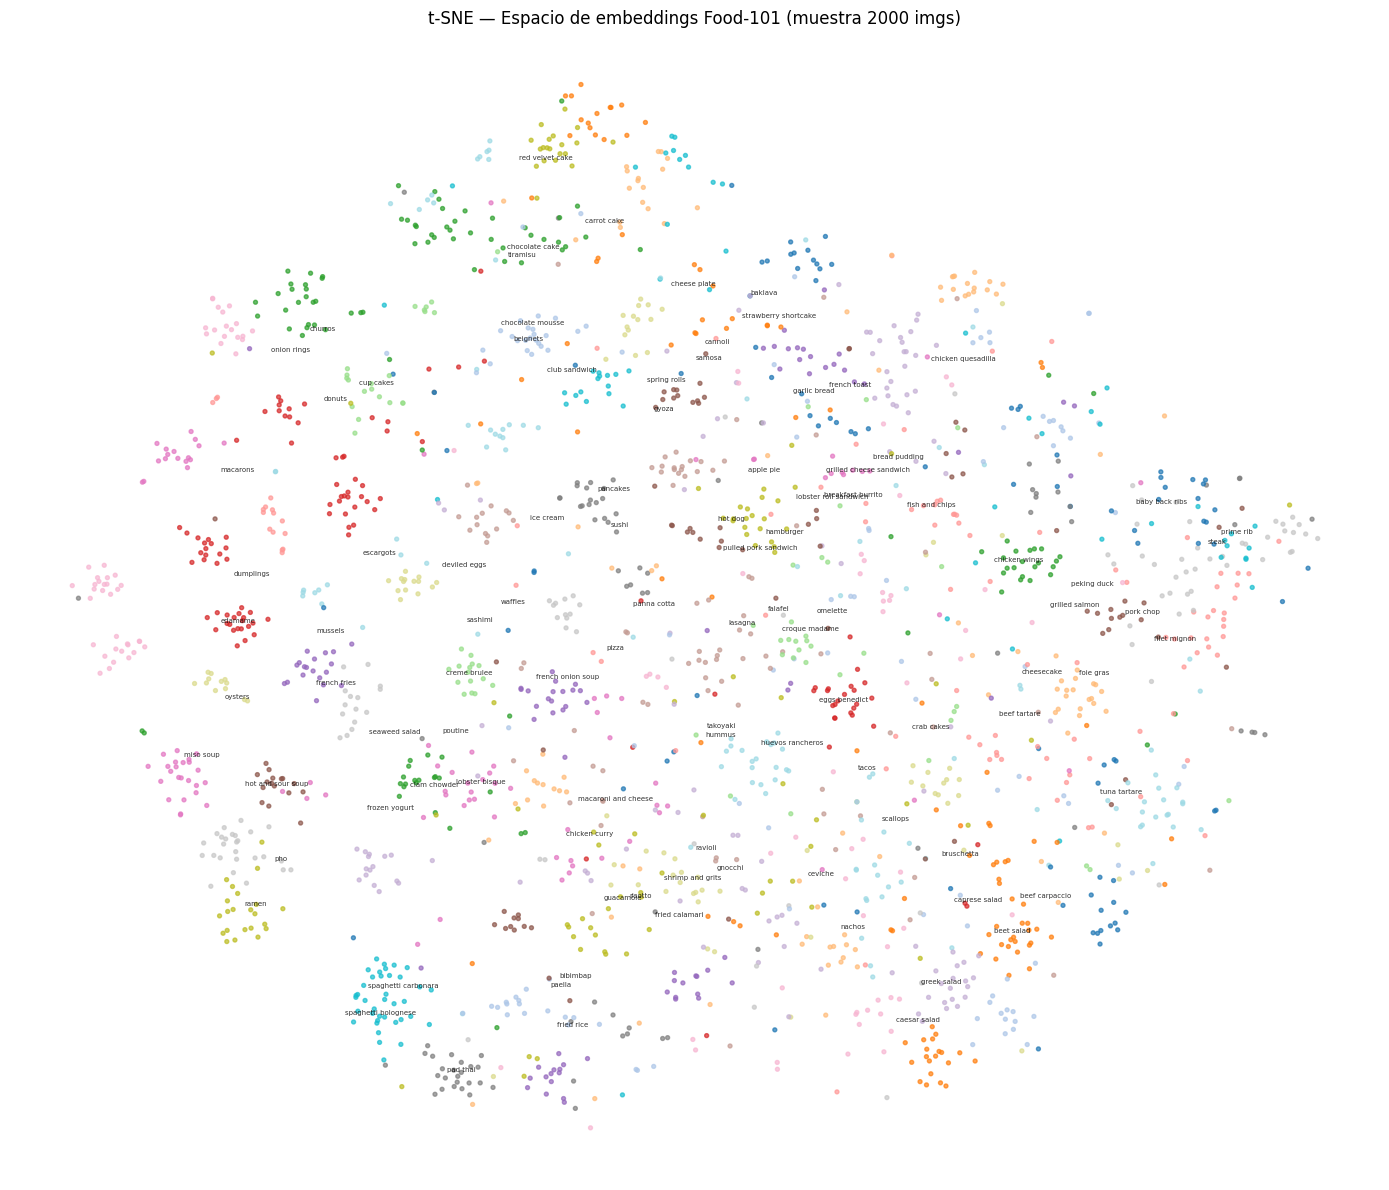

Guardado como tsne_food101.png


In [5]:
# Asignar colores por clase
cmap = plt.cm.get_cmap('tab20', 101)
colors = [cmap(l) for l in labels]

fig, ax = plt.subplots(figsize=(14, 12))
scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=labels, cmap='tab20', s=8, alpha=0.7)
ax.set(title='t-SNE — Espacio de embeddings Food-101 (muestra 2000 imgs)', xlabel='t-SNE 1', ylabel='t-SNE 2')
ax.axis('off')

# Anotar algunos clusters con su nombre de clase
for cls_idx in range(101):
    mask = labels == cls_idx
    if mask.sum() > 0:
        cx, cy = coords_2d[mask, 0].mean(), coords_2d[mask, 1].mean()
        ax.annotate(FOOD101_CLASSES[cls_idx].replace('_', ' '), (cx, cy), fontsize=5, ha='center', alpha=0.8)

plt.tight_layout()
plt.savefig('tsne_food101.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado como tsne_food101.png')

## 🔎 Parte 3 — KNN Retrieval por Similitud Coseno


In [6]:
# Construir índice KNN con similitud coseno (embeddings ya normalizados → producto interno)
knn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn.fit(embeddings_norm)
print('Índice KNN construido')

Índice KNN construido


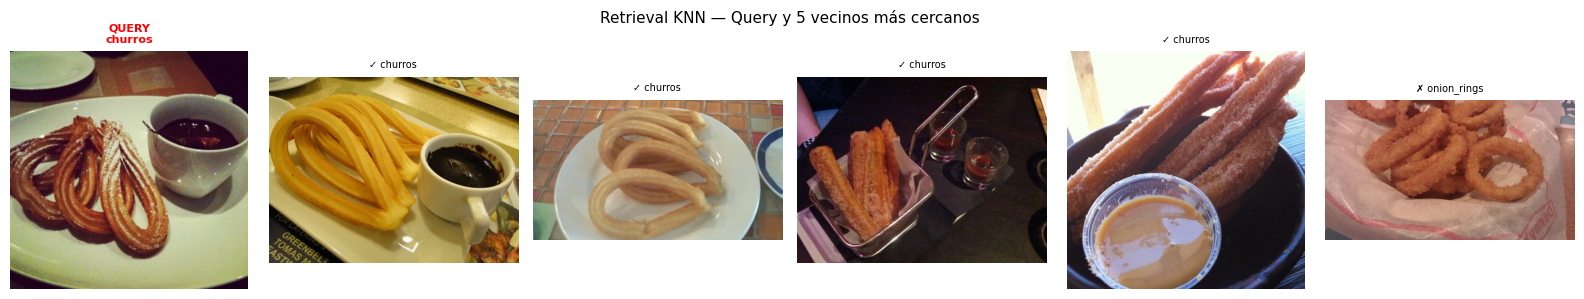

In [7]:
# Demo: dado un query, encontrar las 5 imágenes más similares
# Dataset sin transform para poder visualizar las imágenes originales
raw_sample = Subset(
    datasets.Food101(str(DATA_DIR), split='test', transform=None, download=False),
    sample_idx
)

# Elegir un query al azar
query_idx = rng.integers(len(sample_dataset))
query_img, query_label = raw_sample[query_idx]

distances, neighbor_indices = knn.kneighbors([embeddings_norm[query_idx]])
neighbor_indices = neighbor_indices[0][1:]  # excluir el query mismo

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(query_img)
axes[0].set_title(f'QUERY\n{FOOD101_CLASSES[query_label]}', fontsize=8, color='red', fontweight='bold')
axes[0].axis('off')

for i, nb_idx in enumerate(neighbor_indices):
    nb_img, nb_label = raw_sample[nb_idx]
    axes[i+1].imshow(nb_img)
    match = '✓' if nb_label == query_label else '✗'
    axes[i+1].set_title(f'{match} {FOOD101_CLASSES[nb_label]}', fontsize=7)
    axes[i+1].axis('off')

plt.suptitle('Retrieval KNN — Query y 5 vecinos más cercanos', fontsize=11)
plt.tight_layout()
plt.show()

## 🧮 Parte 4 — Comparativa de Error Calórico: Hard vs Soft

Hipótesis: usar el promedio de los K vecinos más cercanos para estimar las calorías
puede ser más robusto que usar solo la clase predicha (cuando el modelo está inseguro).


In [8]:
from src.nutrition import get_nutrition

# Calcular calorías por ambos métodos para cada imagen de la muestra
hard_errors, soft_errors = [], []

for i in range(len(sample_dataset)):
    true_label = labels[i]
    true_cls = FOOD101_CLASSES[true_label]
    true_nut = get_nutrition(true_cls)
    if true_nut is None:
        continue
    true_kcal = true_nut['calories']
    
    # Hard: usar solo el embedding más cercano (top-1)
    dists, nbrs = knn.kneighbors([embeddings_norm[i]])
    pred_cls = FOOD101_CLASSES[labels[nbrs[0][1]]]  # vecino más cercano ≠ query
    pred_nut = get_nutrition(pred_cls)
    if pred_nut:
        hard_errors.append(abs(pred_nut['calories'] - true_kcal) / (true_kcal + 1e-8))
    
    # Soft: promedio de calorías de los 5 vecinos más cercanos
    neighbor_kcals = []
    for nb_idx in nbrs[0][1:6]:
        nb_cls = FOOD101_CLASSES[labels[nb_idx]]
        nb_nut = get_nutrition(nb_cls)
        if nb_nut:
            neighbor_kcals.append(nb_nut['calories'])
    if neighbor_kcals:
        soft_pred = np.mean(neighbor_kcals)
        soft_errors.append(abs(soft_pred - true_kcal) / (true_kcal + 1e-8))

print(f'Error calórico promedio — Hard (KNN-1): {np.mean(hard_errors)*100:.1f}%')
print(f'Error calórico promedio — Soft (KNN-5): {np.mean(soft_errors)*100:.1f}%')

Error calórico promedio — Hard (KNN-1): 23.3%
Error calórico promedio — Soft (KNN-5): 22.3%


---
## ❓ Preguntas de reflexión

1. **¿El t-SNE muestra clusters claros?** ¿Qué tipos de comida quedan agrupados?
2. **¿Qué categorías son difíciles de separar** en el espacio de embeddings?
3. **¿El soft retrieval reduce el error calórico** respecto a la predicción dura? ¿Por qué?
4. **¿Tiene sentido usar KNN retrieval como fallback** cuando la confianza del clasificador es baja?
